# Buối 1



---
## Bài 1


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
sentences = [
    "machine learning uses algorithms to learn from data",
    "deep learning is a subset of machine learning",
    "neural networks are inspired by the human brain",
    "football is a popular sport around the world",
    "basketball players dribble and shoot to score",
    "athletes train hard to improve their performance",
    "python is a powerful programming language for data science",
    "numpy and pandas are essential libraries for data analysis",
    "data science combines statistics programming and domain knowledge",
    "artificial intelligence will transform the future of technology",
]

vocab = sorted(set(w for s in sentences for w in s.split()))
def to_vector(sentence):
    v = np.zeros(len(vocab), dtype=float)
    for w in sentence.split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in sentences])
print(X.shape)
print(len(sentences), len(vocab))


(10, 59)
10 59


- X.shape: ma trận (10, 59) nghĩa là 10 câu (hàng) và 59 ký tự đặc biệt ko lặp (cột) 
- X[i,j]: số lần từ j xuất hiện trong câu i


### Câu 2 

In [4]:
mean_vector = X.mean(axis=0) #cộng trung bình theo cột (10, 59) -> (59, ) hay hiểu là (1, 59)
X_centered = X - mean_vector # (10, 59) - (59, ) -> (10, 59) - (1, 59) = (10, 59)

print(X.shape)
print(X_centered.shape)


(10, 59)
(10, 59)


Broadcasting từ (59, ) lên (10, 59) do numpy / pytorch sẽ broadcast nếu có dim = 1



### Câu 3


In [5]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True))
    Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True)) 
    return Xn @ Yn.T

sim_matrix = cosine_similarity(X)
print(np.round(sim_matrix, 2))


[[1.   0.34 0.   0.   0.13 0.13 0.12 0.12 0.12 0.  ]
 [0.34 1.   0.   0.22 0.   0.   0.21 0.   0.   0.11]
 [0.   0.   1.   0.12 0.   0.   0.   0.12 0.   0.12]
 [0.   0.22 0.12 1.   0.   0.   0.24 0.   0.   0.12]
 [0.13 0.   0.   0.   1.   0.14 0.   0.13 0.13 0.  ]
 [0.13 0.   0.   0.   0.14 1.   0.   0.   0.   0.  ]
 [0.12 0.21 0.   0.24 0.   0.   1.   0.22 0.35 0.  ]
 [0.12 0.   0.12 0.   0.13 0.   0.22 1.   0.24 0.  ]
 [0.12 0.   0.   0.   0.13 0.   0.35 0.24 1.   0.  ]
 [0.   0.11 0.12 0.12 0.   0.   0.   0.   0.   1.  ]]


In [ ]:
def search(query_sentence, top_k=3):
    query = to_vector(query_sentence).reshape(1, -1) #chuyển câu thành vector rồi reshape lại thành (1, số ký tự) thì mới bỏ vô cosine đc vì cosine nó yêu cầu phải là 2D 
    sims = cosine_similarity(query, X).flatten()  #flatten thành (n, )
    ranked = np.argsort(sims)[::-1] #ranking thôi
    print(f'"{query_sentence}"')

    results = []

    for rank in range(top_k):
        idx = ranked[rank]
        score = sims[idx]
        sentence = sentences[idx]
        print(f"{rank+1}. {score:}: {sentence}")

        results.append((idx, score))

    return results



search("machine learning algorithms and neural networks")
search("football sport score train hard")
search("python programming data science libraries")



"machine learning algorithms and neural networks"
1. 0.4330127018922194: machine learning uses algorithms to learn from data
2. 0.3872983346207417: deep learning is a subset of machine learning
3. 0.2886751345948129: neural networks are inspired by the human brain
"football sport score train hard"
1. 0.3380617018914066: athletes train hard to improve their performance
2. 0.3162277660168379: football is a popular sport around the world
3. 0.1690308509457033: basketball players dribble and shoot to score
"python programming data science libraries"
1. 0.5962847939999438: python is a powerful programming language for data science
2. 0.47434164902525683: data science combines statistics programming and domain knowledge
3. 0.2981423969999719: numpy and pandas are essential libraries for data analysis


[(np.int64(6), np.float64(0.5962847939999438)),
 (np.int64(8), np.float64(0.47434164902525683)),
 (np.int64(7), np.float64(0.2981423969999719))]

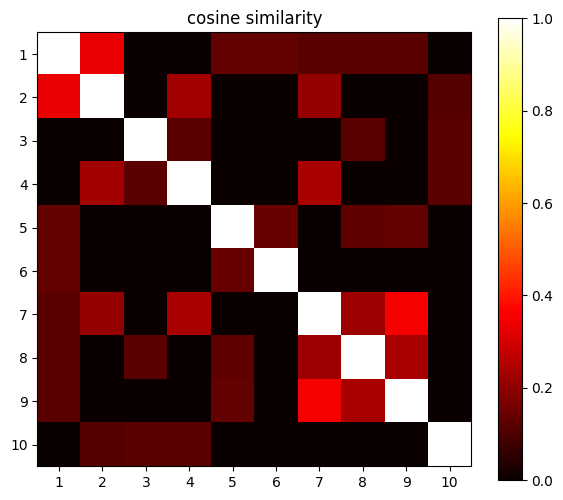

In [7]:
plt.figure(figsize=(7, 6))
plt.imshow(sim_matrix, cmap='hot')
plt.colorbar()
plt.xticks(range(10), [i+1 for i in range(10)])
plt.yticks(range(10), [i+1 for i in range(10)])
plt.title('cosine similarity')
plt.show()


**Nhận xét:**
- Cặp giống nhau nhất: C1-C2 (*machine learning* & *deep learning*) và C8-C9 — cùng chủ đề
- Cặp khác biệt nhất: C4 (football) vs C7 (python programming) — cosine ~ 0.0 (không có từ chung)
- Kết quả khớp trực giác vì các câu cùng lĩnh vực phân cụm rõ ràng trong không gian vector


---
## Bài 2 



### Câu 4 

In [8]:
Xc = X - X.mean(axis=0)
print(Xc.shape)


(10, 59)


In [9]:
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
print(U.shape, S.shape, Vt.shape)
print(S[:5])


(10, 10) (10,) (10, 59)
[3.39791122 3.26130873 3.11453173 2.76118856 2.65866231]


In [10]:
Lcoords = U[:, :2] * S[:2]
print(Lcoords.round(3))


[[-0.433  0.707]
 [-1.997  1.281]
 [-0.029 -1.63 ]
 [-1.048 -0.08 ]
 [ 0.633 -0.617]
 [ 0.07  -0.802]
 [ 0.513  1.584]
 [ 1.664  0.095]
 [ 1.462  0.767]
 [-0.834 -1.304]]


### Scatter Plot 2D (LSA)

ML/AI (đỏ), Thể thao (xanh lá), Công nghệ (xanh dương)

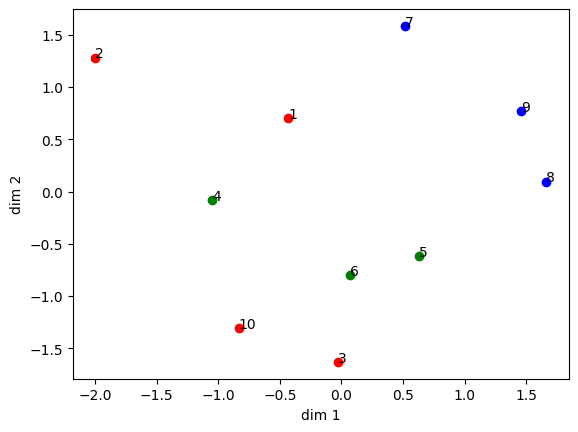

In [11]:
topic = ['ml','ml','ml','sport','sport','sport','tech','tech','tech','ml']
cl = {'ml':'r', 'sport':'g', 'tech':'b'}

plt.figure()
for i in range(len(Lcoords)):
    plt.scatter(Lcoords[i, 0], Lcoords[i, 1], c=cl[topic[i]])
    plt.text(Lcoords[i, 0], Lcoords[i, 1], str(i+1))

plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.savefig('lsa_scatter.png')
plt.show()


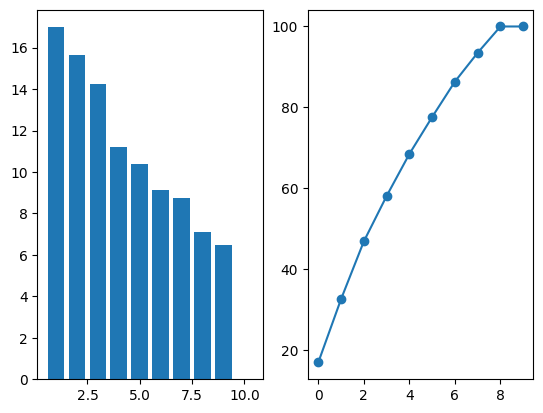

2 chiều đầu: 32.6 %


In [12]:
var = S**2 / (S**2).sum()
cum = np.cumsum(var)

plt.subplot(1, 2, 1)
plt.bar(range(1, len(S)+1), var * 100)
plt.subplot(1, 2, 2)
plt.plot(cum * 100, 'o-')
plt.savefig('explained_variance.png')
plt.show()

print('2 chiều đầu:', round(cum[1] * 100, 1), '%')


**Nhận xét LSA:**
- Các câu cùng chủ đề nằm gần nhau và phân cụm rõ ràng.
- chiều 1 phân biệt các lĩnh vực, chiều 2 tách biệt các chủ đề nhỏ hơn.
- các singular value đóng vai trò eigenvalue với chiều S lớn nhất mang nhiều thông tin đúng nhất
- Với tập nhỏ (10 câu, 59 từ), 2 chiều đầu đã giải thích phần lớn phương sai -> LSA hiệu quả cho classify sơ bộ.
